### Importing the Libraries required

In [3]:
import pandas as pd
import sklearn
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


#### Reading the Insurance Data

In [4]:
InsuranceDF = pd.read_csv("Insurance.csv")

##### Sanity Check

In [5]:
InsuranceDF.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


We can see that all the attributes are present in the dataset

##### Check for the NULLs and the Counts for all attributes

In [6]:
InsuranceDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


##### As per the info we can see we have 1338 entries and we dont have any NULLs in any of the attributes

#### We use describe to find the mean, standard deviation and the Percentiles

In [7]:
InsuranceDF.describe(percentiles=[0.25,0.5,0.75,0.9, 0.95],include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


We can see that attributes "age" and "bmi" are distributed throuh out the percentile but "children" and "charges" seems to be skewed

### Attriubte Analysis

##### Histograms of Numerical Attributes

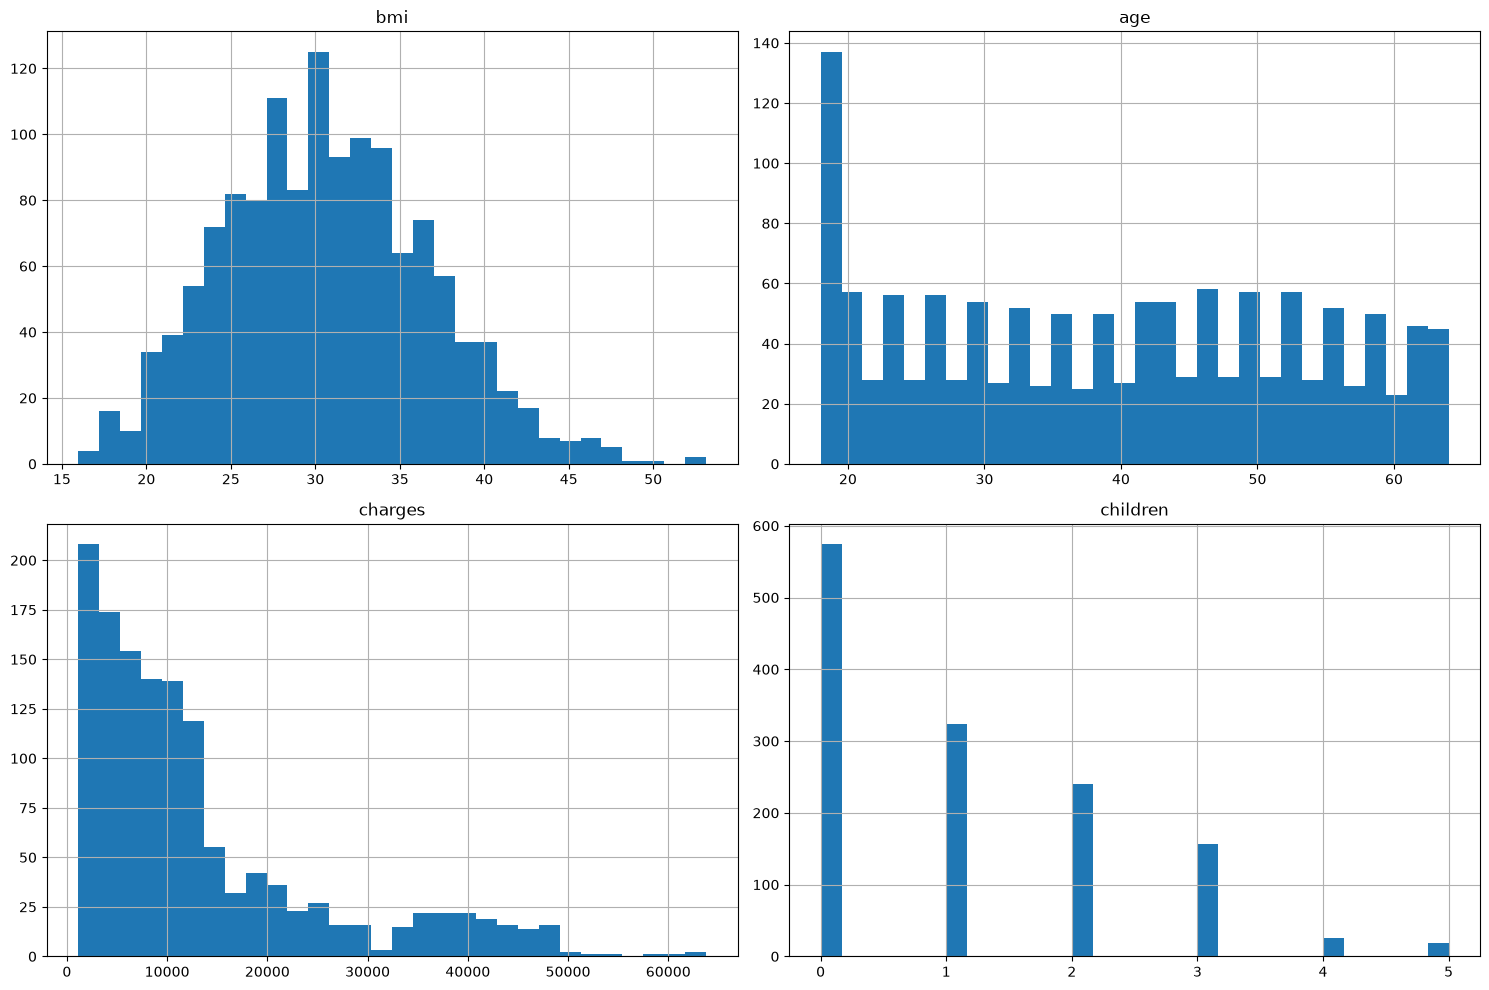

In [8]:
# Histograms for 'age', 'bmi', 'charges' , 'Children'
InsuranceDF[['bmi', 'age', 'charges','children']].hist(bins=30, figsize=(15, 10), layout=(2, 2))
plt.tight_layout()
plt.show()

We can from the above graphs can see that apart from the "bmi" there seems to be skewness to the rest of the attributes

#### Plotting for the Skewness

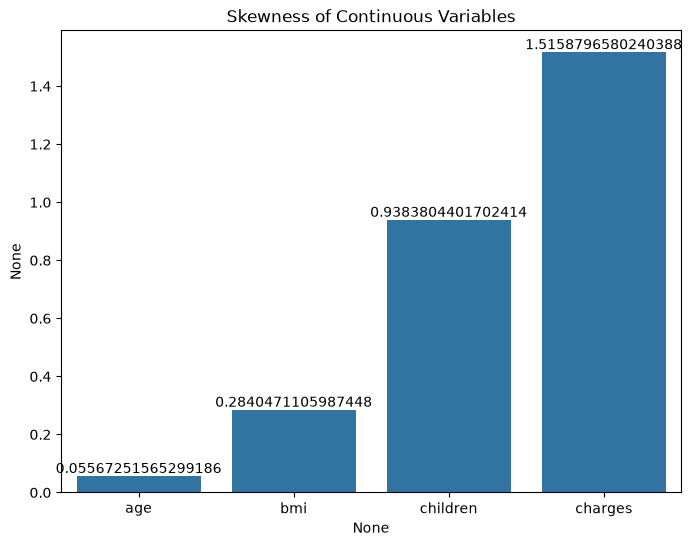

In [9]:
skewness = InsuranceDF[['age', 'bmi', 'children', 'charges']].skew()

# Plot it
plt.figure(figsize=(8, 6))
sns.barplot(x=InsuranceDF[['age', 'bmi', 'children', 'charges']].columns, y=skewness)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
    
plt.title('Skewness of Continuous Variables')
plt.show()

We can see that the charges is having high level of skewness we will comeback to this later

#### Plotting for the non numeric attributes

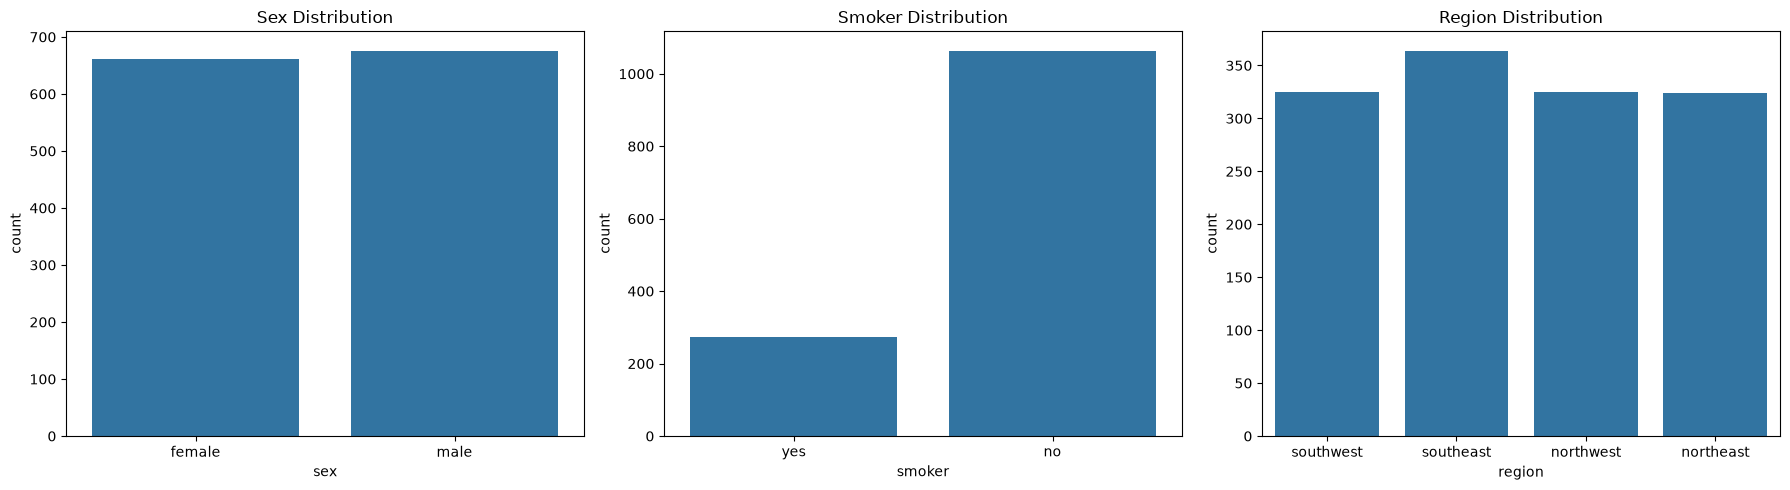

In [10]:
# Plotting to check the distribution of sex , smokers and region which are categorical attributes

fig, axs = plt.subplots(ncols=3, figsize=(18, 5))

# Plotting for 'sex'
sns.countplot(x='sex', data=InsuranceDF, ax=axs[0])
axs[0].set_title('Sex Distribution')


# Plotting for 'smoker'
sns.countplot(x='smoker', data=InsuranceDF, ax=axs[1])
axs[1].set_title('Smoker Distribution')

# Plotting for 'region'
sns.countplot(x='region', data=InsuranceDF, ax=axs[2])
axs[2].set_title('Region Distribution')

plt.tight_layout()
plt.show()


We can see from the graphs that the smoker is heavily skewed compared to the other catagorical attributes

Let us try to check each of these attributes againt charges and how it is 

#### sex against charges

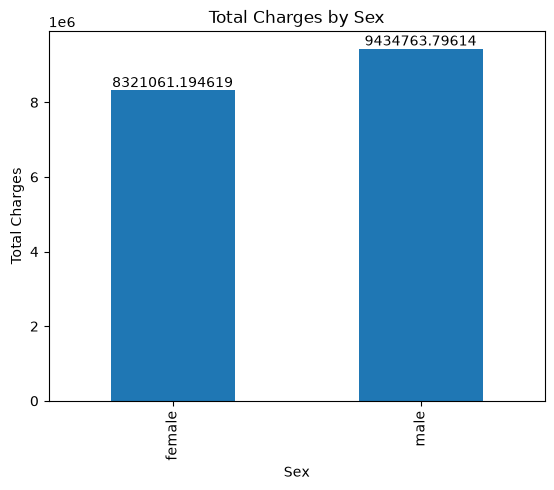

In [11]:
grouped_data = InsuranceDF.groupby('sex')['charges'].sum()

# Plotting the bar chart
ax = grouped_data.plot(kind='bar')
plt.xlabel('Sex')
plt.ylabel('Total Charges')
plt.title('Total Charges by Sex')

# Add the sum of charges as labels on top of each bar
for i, v in enumerate(grouped_data):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

From the above graph we can see that sex is evenly distributed in count and againt charges

#### smoker against charges

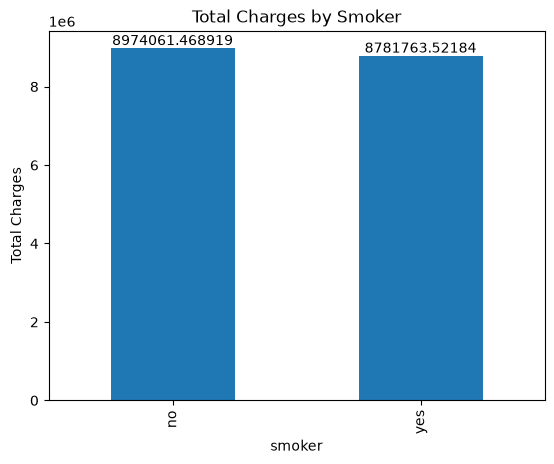

In [12]:
grouped_data = InsuranceDF.groupby('smoker')['charges'].sum()

# Plotting the bar chart
ax = grouped_data.plot(kind='bar')
plt.xlabel('smoker')
plt.ylabel('Total Charges')
plt.title('Total Charges by Smoker')

# Add the sum of charges as labels on top of each bar
for i, v in enumerate(grouped_data):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

Form this graph we can see that even though that smoker attribute is skewed in count but against charges we can see that is almost evenly distributes

### Scatter Plot of the Numerical data

This is perforemd to check the againt two numerical variables

array([[<Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='bmi', ylabel='age'>,
        <Axes: xlabel='children', ylabel='age'>,
        <Axes: xlabel='charges', ylabel='age'>],
       [<Axes: xlabel='age', ylabel='bmi'>,
        <Axes: xlabel='bmi', ylabel='bmi'>,
        <Axes: xlabel='children', ylabel='bmi'>,
        <Axes: xlabel='charges', ylabel='bmi'>],
       [<Axes: xlabel='age', ylabel='children'>,
        <Axes: xlabel='bmi', ylabel='children'>,
        <Axes: xlabel='children', ylabel='children'>,
        <Axes: xlabel='charges', ylabel='children'>],
       [<Axes: xlabel='age', ylabel='charges'>,
        <Axes: xlabel='bmi', ylabel='charges'>,
        <Axes: xlabel='children', ylabel='charges'>,
        <Axes: xlabel='charges', ylabel='charges'>]], dtype=object)

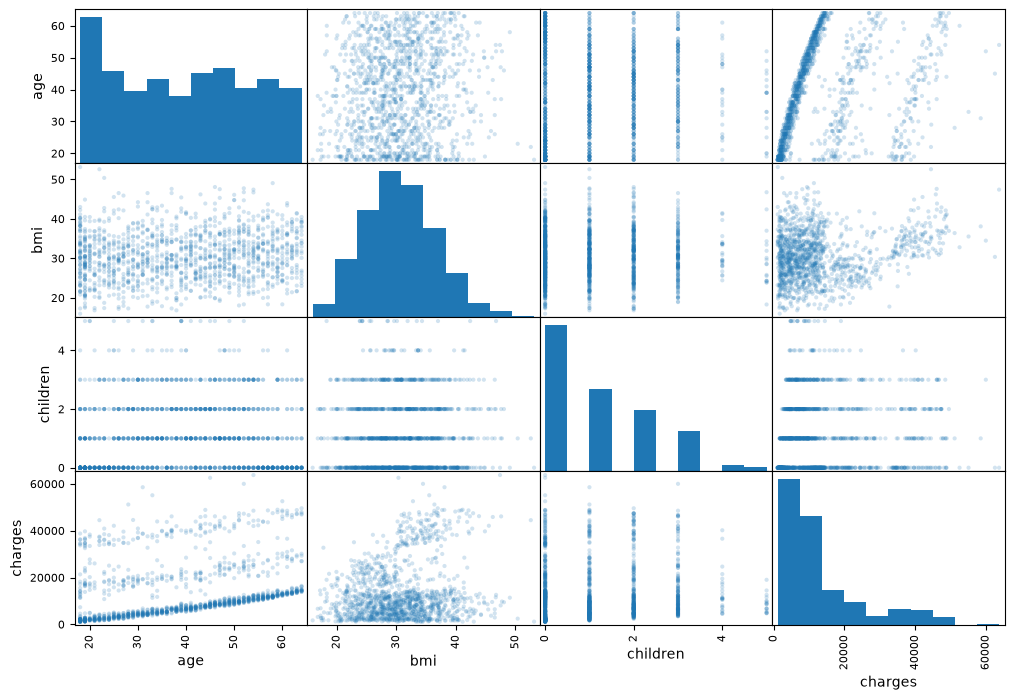

In [13]:
pd.plotting.scatter_matrix(InsuranceDF, figsize=(12, 8),alpha=0.2)

For the aboce graphs we can see that the age is linear againt charges as well as bmi

#### Age against charges with smoker as the hue

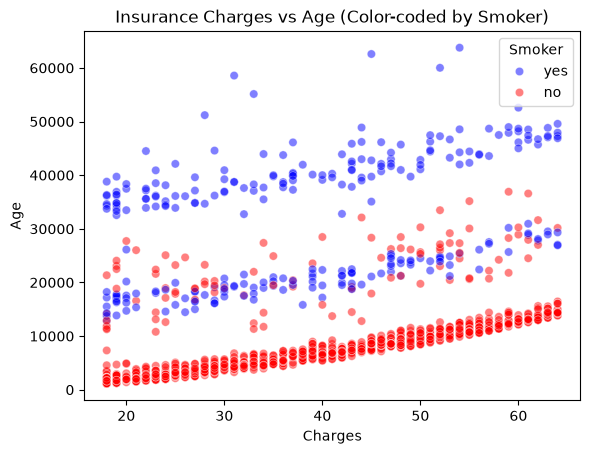

In [14]:
sns.scatterplot(x='age', y='charges', hue='smoker', data=InsuranceDF, palette=['blue', 'red'], alpha =0.5)

plt.xlabel('Charges')
plt.ylabel('Age')
plt.title('Insurance Charges vs Age (Color-coded by Smoker)')
plt.legend(title='Smoker', loc='upper right')
plt.show()

from the above graphs we can see from this graph that the smokers having "yes" is paying more charges and also we can see there is a lot of data populated below 10000

### Correlation Graph

We have encoded the catagorical values to be represented in a numerical format

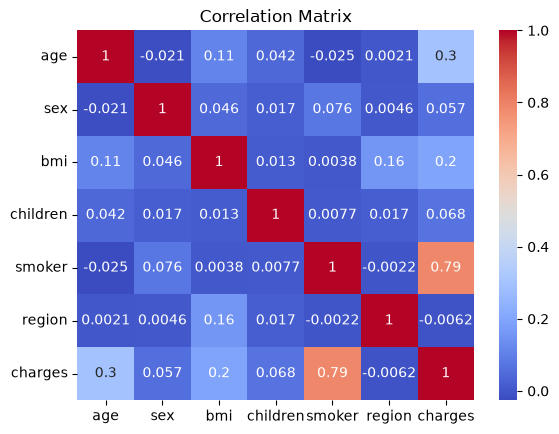

In [15]:
encoded_data = InsuranceDF.copy()

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Encode the categorical variables
encoded_data['sex'] = label_encoder.fit_transform(encoded_data['sex'])
encoded_data['smoker'] = label_encoder.fit_transform(encoded_data['smoker'])
encoded_data['region'] = label_encoder.fit_transform(encoded_data['region'])

# Select the desired attributes for the correlation matrix
attributes = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
selected_data = encoded_data[attributes]

# Create the correlation matrix
corr_matrix = selected_data.corr()

# Plotting the correlation matrix as a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

From the Correlation matric we can see that smoker and charges have high positive correlation and we can also see region is not having realtion with the charges, we believe we can drop this attributes we will test with this later

## Data Pre-processing and cleaning

### Log Transformation Charges attribute

In [16]:
# Transformation: As 'charges' is extremely sklewed positively. Few of the outliers have extremely high value.
#     We are applying logarthimic transfomration to it to make it more symmetric. 
#     Another important point to note is that making charges logarthimic will still preserve the efficiency of calculation
#     in terms of R2, MAE and RMSE. Hence we can safely apply logarthmic transformation to it. 
encoded_data['charges'] = np.log(encoded_data['charges'])

#### Before and after the transformation

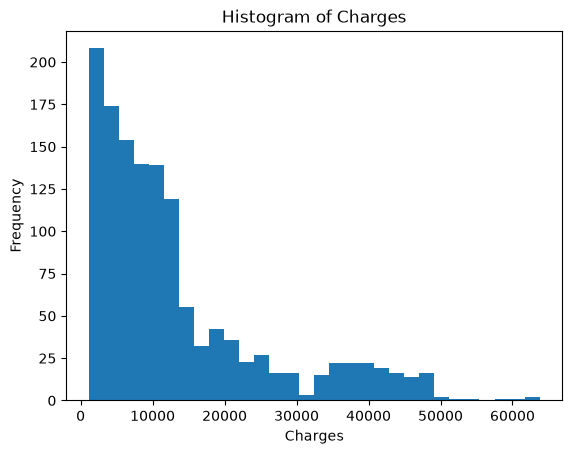

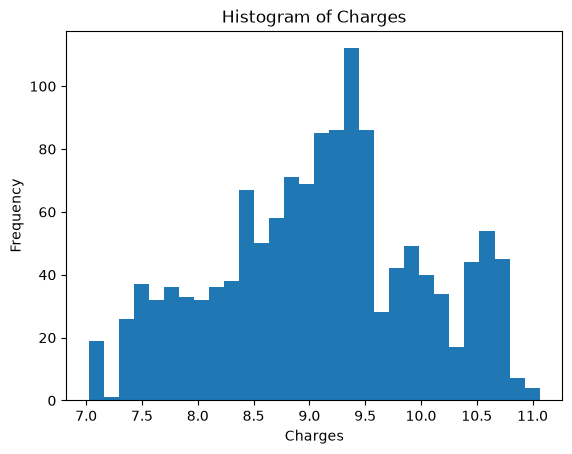

In [17]:
plt.hist(InsuranceDF['charges'], bins=30)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Histogram of Charges')
plt.show()

plt.hist(encoded_data['charges'], bins=30)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Histogram of Charges')
plt.show()

### Using Polynomial Features

We are usnig Polynomial Features for the below reasons
- Capturing Nonlinear Relationships
- Increased Model Flexibility
- Improved Model Generalization
- Overcoming Linearity Assumptions

###  We are going to expirement with multiple degrees of polynomial along with Kfold cross validation and Linear Regression model to check the efficiency of the model

In [18]:
# Assuming you have a DataFrame named InsuranceDF with your data
# Assuming 'X' represents the feature variables and 'y' represents the target variable ('charges')

# Split the data into training and testing sets
X = encoded_data.drop('charges', axis=1)  # Features (all columns except 'charges')
y = encoded_data['charges']  # Target variable ('charges')

In [19]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statistics

model1 = LinearRegression()
model2 = LinearRegression()

k = 5
kf = KFold(n_splits=k)
kf2 = KFold(n_splits=k)



for d in range(1,5):
    
    polynomial_converter = PolynomialFeatures(degree=d, include_bias = False)
    poly_features = polynomial_converter.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.2, random_state=42)
    X_train2, X_test2, y_train2, y_test2 = train_test_split(poly_features, y, test_size=0.9, random_state=42)
    
    
    scores = []
    scores2 = []
    print("========================")
    print("Iteration : ",d)
    
    
    
    for train_index, test_index in kf.split(X_train):
        X_train1, X_val = X_train[train_index], X_train[test_index]
        y_train1, y_val = y_train.iloc[train_index], y_train.iloc[test_index]

        # Train the model on the training folds
        model1.fit(X_train1, y_train1)

        # Make predictions on the test fold
        fold_predictions = model1.predict(X_val)
        
        fold_score = np.sqrt(mean_squared_error(y_val, fold_predictions))
        scores.append(fold_score)
        
    
    for train_index, test_index in kf2.split(X_train2):
        X_train3, X_val = X_train2[train_index], X_train2[test_index]
        y_train3, y_val = y_train2.iloc[train_index], y_train2.iloc[test_index]

        # Train the model on the training folds
        model2.fit(X_train3, y_train3)

        # Make predictions on the test fold
        fold_predictions = model2.predict(X_val)
        
        fold_score = np.sqrt(mean_squared_error(y_val, fold_predictions))
        scores2.append(fold_score)

        
#     print("Mean MSE:", statistics.mean(scores))
#     print("Standard Deviation of MSE:", statistics.stdev(scores))
    
#     print("Mean MSE for 2nd Model:", statistics.mean(scores2))
#     print("Standard Deviation of MSE for second model2:", statistics.stdev(scores2))
    
    scores_df = pd.DataFrame({
    'Split': ['80% Train / 20% Test', '10% Train / 90% Test'],
    'mean of mse': [statistics.mean(scores), statistics.mean(scores2)],
    'SD of mse': [statistics.stdev(scores), statistics.stdev(scores2)],
    })
    
    print ("Scores for the K Fold")
    print(scores_df)
    print("----------------------------")
    # Train the model on the entire dataset
    model1.fit(X_train, y_train)
    model2.fit(X_train2, y_train2)

    # Predict for the test set (X_test)
     # Replace with your test set
    test_predictions = model1.predict(X_test)
    test_predictions2 = model2.predict(X_test2)
    
    rmse1 = np.sqrt(mean_squared_error(y_test, test_predictions))
    r2_1 = r2_score(y_test, test_predictions)
    mae1 = mean_absolute_error(y_test, test_predictions)
    
    rmse2 = np.sqrt(mean_squared_error(y_test2, test_predictions2))
    r2_2 = r2_score(y_test2, test_predictions2)
    mae2 = mean_absolute_error(y_test2, test_predictions2)
    
  
    results_df = pd.DataFrame({
    'Split': ['80% Train / 20% Test', '10% Train / 90% Test'],
    'RMSE': [rmse1, rmse2],
    'R2 Score': [r2_1, r2_2],
    'MAE': [mae1, mae2]
    })
    print("Evaluation for the Insurance data")
    print(results_df)
    print("============================")

Iteration :  1
Scores for the K Fold
                  Split  mean of mse  SD of mse
0  80% Train / 20% Test     0.450733   0.042195
1  10% Train / 90% Test     0.461900   0.034455
----------------------------
Evaluation for the Insurance data
                  Split      RMSE  R2 Score       MAE
0  80% Train / 20% Test  0.421382  0.802520  0.270821
1  10% Train / 90% Test  0.453706  0.755622  0.302395
Iteration :  2
Scores for the K Fold
                  Split  mean of mse  SD of mse
0  80% Train / 20% Test     0.376571   0.043881
1  10% Train / 90% Test     0.421850   0.028734
----------------------------
Evaluation for the Insurance data
                  Split      RMSE  R2 Score       MAE
0  80% Train / 20% Test  0.347598  0.865623  0.196005
1  10% Train / 90% Test  0.439666  0.770513  0.290418
Iteration :  3
Scores for the K Fold
                  Split  mean of mse  SD of mse
0  80% Train / 20% Test     0.382171   0.048186
1  10% Train / 90% Test     0.739500   0.234112
-------

### From the outputs of the above code we can see that the for the KFold of 5 and polynomial degreee 2 we are getting the best results 

#### By removing redundant data we will try to reun the model for the above fit we have obtained

In [20]:
X_reduced = X.drop(columns=['region','sex'])

In [21]:
model3 = LinearRegression()
model4 = LinearRegression()


polynomial_converter = PolynomialFeatures(degree=2, include_bias = False)
poly_features = polynomial_converter.fit_transform(X_reduced)

X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(poly_features, y, test_size=0.9, random_state=42)


# Train the model on the entire dataset
model3.fit(X_train, y_train)
model4.fit(X_train2, y_train2)

# Predict for the test set (X_test)
 # Replace with your test set
test_predictions = model3.predict(X_test)
test_predictions2 = model4.predict(X_test2)

rmse1 = np.sqrt(mean_squared_error(y_test, test_predictions))
r2_1 = r2_score(y_test, test_predictions)
mae1 = mean_absolute_error(y_test, test_predictions)

rmse2 = np.sqrt(mean_squared_error(y_test2, test_predictions2))
r2_2 = r2_score(y_test2, test_predictions2)
mae2 = mean_absolute_error(y_test2, test_predictions2)


results_df1 = pd.DataFrame({
'Split': ['80% Train / 20% Test', '10% Train / 90% Test'],
'RMSE': [rmse1, rmse2],
'R2 Score': [r2_1, r2_2],
'MAE': [mae1, mae2]
})
print("Evaluation for the Insurance data")
results_df1

Evaluation for the Insurance data


,Split,RMSE,R2 Score,MAE
0,80% Train / 20% Test,0.357821,0.857602,0.205777
1,10% Train / 90% Test,0.388507,0.820811,0.231562


As we remove the attributes we are not seeing any reduction in the erros but a slight increase in the error so we leave the model without dropping any attributes

In [23]:
import pickle

# Assume model is your trained model
with open("model.pkl", "wb") as file:
    pickle.dump(model1, file)